In [1]:
!pip install -q nemo-curator datasets pillow torchvision



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


## Load ScienceQA

In [2]:
from datasets import load_dataset

dataset = load_dataset("TheMrguiller/ScienceQA", split="train")

print(dataset)
print(dataset[0].keys())


README.md: 0.00B [00:00, ?B/s]

(…)-00000-of-00002-14fa9bb04c22041e.parquet:   0%|          | 0.00/249M [00:00<?, ?B/s]

(…)-00001-of-00002-f2a611b537db2095.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

(…)-00000-of-00001-150ca5454bb2d715.parquet:   0%|          | 0.00/126M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16966 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4242 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'question', 'choices', 'answer', 'solution', 'CTH'],
    num_rows: 16966
})
dict_keys(['image', 'question', 'choices', 'answer', 'solution', 'CTH'])


## Keep only samples with images

In [3]:
dataset = dataset.filter(lambda x: x["image"] is not None)
print("Samples with images:", len(dataset))


Filter:   0%|          | 0/16966 [00:00<?, ? examples/s]

Samples with images: 8248


In [4]:
print("Total image samples:", len(dataset))


Total image samples: 8248


## Convert to image-aware records

In [12]:
import os
import json

os.makedirs("data/scienceqa_images", exist_ok=True)
jsonl_path = "data/scienceqa_images/metadata.jsonl"


## Save images + metadata

In [13]:
from PIL import Image

with open(jsonl_path, "w", encoding="utf-8") as f:
    for i, row in enumerate(dataset):
        img_path = f"data/scienceqa_images/img_{i:05d}.png"
        row["image"].save(img_path)

        record = {
            "id": f"IMG_{i:05d}",
            "image_path": img_path,
            "question": row["question"],
            "choices": row["choices"],
            "answer": row["answer"],
            "solution": row["solution"],
        }

        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print("Saved images + metadata")


Saved images + metadata


## Validate images (size, readability)

In [14]:
def is_valid_image(path):
    try:
        img = Image.open(path)
        img.verify()
        return img.width >= 64 and img.height >= 64
    except:
        return False


## Filter broken / tiny images

In [15]:
valid_records = []

with open(jsonl_path, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        if is_valid_image(record["image_path"]):
            valid_records.append(record)

print("Valid images:", len(valid_records))


Valid images: 8125


## save curated dataset

In [11]:
curated_path = "data/scienceqa_images_curated.jsonl"

with open(curated_path, "w", encoding="utf-8") as f:
    for r in valid_records:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print("Curated dataset saved:", curated_path)


Curated dataset saved: data/scienceqa_images_curated.jsonl


## Show sample images

(-0.5, 488.5, 170.5, -0.5)

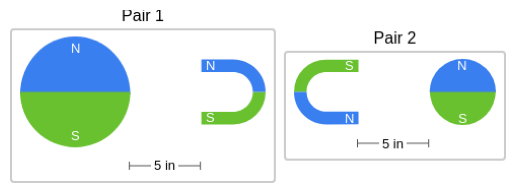

In [39]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("data/scienceqa_images/img_00018.png")
plt.imshow(img)
plt.axis("off")


## Preview one curated record

In [31]:
import json

with open("data/scienceqa_images_curated.jsonl", "r", encoding="utf-8") as f:
    for i in range(10):
        rec = json.loads(next(f))
        print(rec["image_path"])

   




data/scienceqa_images/img_00000.png
data/scienceqa_images/img_00001.png
data/scienceqa_images/img_00002.png
data/scienceqa_images/img_00003.png
data/scienceqa_images/img_00004.png
data/scienceqa_images/img_00005.png
data/scienceqa_images/img_00006.png
data/scienceqa_images/img_00007.png
data/scienceqa_images/img_00009.png
data/scienceqa_images/img_00010.png


In [40]:
import json

target_image = "img_00018.png"
sample = None

with open("data/scienceqa_images_curated.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        if rec["image_path"].endswith(target_image):
            sample = rec
            break

if sample is None:
    raise ValueError(f"{target_image} not found in curated dataset")

sample


{'id': 'IMG_00018',
 'image_path': 'data/scienceqa_images/img_00018.png',
 'question': '[QUESTION]Think about the magnetic force between the magnets in each pair. Which of the following statements is true?',
 'choices': '[OPTIONS](A) The magnitude of the magnetic force is greater in Pair 2. (B) The magnitude of the magnetic force is greater in Pair 1. (C) The magnitude of the magnetic force is the same in both pairs.',
 'answer': 'The magnitude of the magnetic force is greater in Pair 1.',
 'solution': 'The magnets in Pair 2 attract. The magnets in Pair 1 repel. But whether the magnets attract or repel affects only the direction of the magnetic force. It does not affect the magnitude of the magnetic force.\nMagnet sizes affect the magnitude of the magnetic force. Imagine magnets that are the same shape and made of the same material. The larger the magnets, the greater the magnitude of the magnetic force between them.\nMagnet A is the same size in both pairs. But Magnet B is larger in P

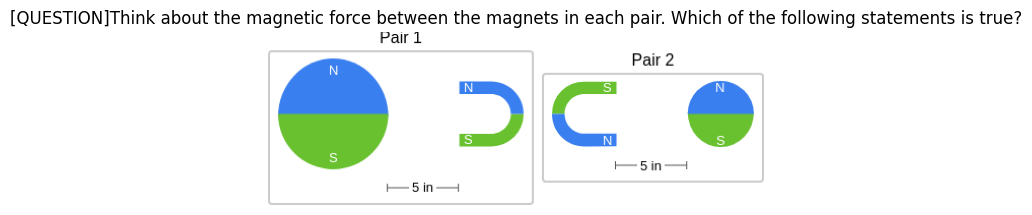

In [43]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(sample["image_path"])

plt.imshow(img)
plt.axis("off")
plt.title(sample["question"])
plt.show()
